# PyTorch fine-tuning of ResNet50

## Notebook set-up

### Imports

In [ ]:
# Standard library imports
import pickle
from pathlib import Path

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

# Package imports
from image_classification_tools.pytorch.data import (
    load_dataset, prepare_splits, create_dataloaders
)
from image_classification_tools.pytorch.evaluation import evaluate_model
from image_classification_tools.pytorch.plotting import (
    plot_sample_images, plot_learning_curves, 
    plot_confusion_matrix, plot_class_probability_distributions,
    plot_evaluation_curves
)

from image_classification_tools.pytorch.training import train_model

Using device: cuda:1


### Configuration

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(315)
np.random.seed(315)

# Check for GPU availability
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Path to the CIFAR-10 dataset
data_dir = Path('../data/pytorch/cifar10')

# Models directory and filepath
models_dir = Path('../models/pytorch')
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / 'rgb_cnn.pth'

# Performance results directory and file path
results_dir = Path('../data/pytorch/performance_results')
results_dir.mkdir(parents=True, exist_ok=True)
results_path = results_dir / 'rgb_cnn_results.pkl'

# CIFAR-10 class names in class order
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

num_classes = len(class_names)

Using device: cuda:1


### Hyperparameters

In [3]:
validation_size = 10000
batch_size = 64
learning_rate = 1e-5
epochs = 20  # Early stopping will halt if validation accuracy stops improving
print_every = 1

## 1. Load and preprocess CIFAR-10 data

CIFAR-10 contains 32x32 color images (3 channels) across 10 classes. ResNet50 was trained on 224x224 color images and classifies images into 1000 categories.

### 1.1. Visualize sample images

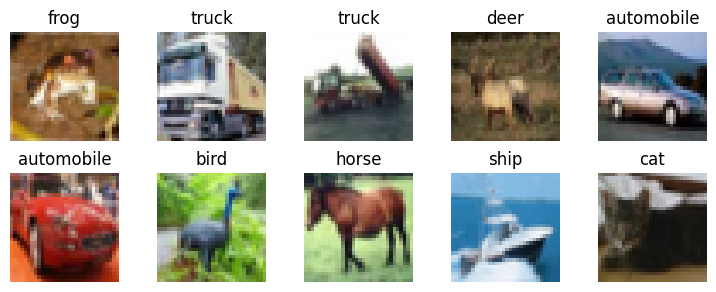

In [4]:
# Get a sample dataset for visualization
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
sample_dataset = datasets.CIFAR10(root=data_dir, transform=transform)
                                    
# Plot first 10 images from the training dataset
fig, axes = plot_sample_images(sample_dataset, class_names)
plt.show()

### 1.2. Define preprocessing transform

In [5]:
# Define basic input transforms (RGB) - no resize needed, we'll adapt the model
# to the CIFAR-10 image size later
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [6]:
train_dataset = load_dataset(
    data_source=datasets.CIFAR10,
    transform=transform,
    root=data_dir,
    train=True
)

test_dataset = load_dataset(
    data_source=datasets.CIFAR10,
    transform=transform,
    root=data_dir,
    train=False
)

### 1.4. Make training, validation split

In [7]:
train_dataset, val_dataset, test_dataset = prepare_splits(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    val_size=validation_size
)

### 1.5. Create dataloaders

In [8]:
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset, val_dataset, test_dataset,
    batch_size=batch_size,
    preload_to_memory=True,
    device=device
)

print(f'Training batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Training batches: 625
Validation batches: 157
Test batches: 157


## 2. ResNet50

### 2.1. Load model

In [9]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

for name, module in model.named_modules():
    print(f'Name: {name}, Module Type: {module.__class__.__name__}')

Name: , Module Type: ResNet
Name: conv1, Module Type: Conv2d
Name: bn1, Module Type: BatchNorm2d
Name: relu, Module Type: ReLU
Name: maxpool, Module Type: MaxPool2d
Name: layer1, Module Type: Sequential
Name: layer1.0, Module Type: Bottleneck
Name: layer1.0.conv1, Module Type: Conv2d
Name: layer1.0.bn1, Module Type: BatchNorm2d
Name: layer1.0.conv2, Module Type: Conv2d
Name: layer1.0.bn2, Module Type: BatchNorm2d
Name: layer1.0.conv3, Module Type: Conv2d
Name: layer1.0.bn3, Module Type: BatchNorm2d
Name: layer1.0.relu, Module Type: ReLU
Name: layer1.0.downsample, Module Type: Sequential
Name: layer1.0.downsample.0, Module Type: Conv2d
Name: layer1.0.downsample.1, Module Type: BatchNorm2d
Name: layer1.1, Module Type: Bottleneck
Name: layer1.1.conv1, Module Type: Conv2d
Name: layer1.1.bn1, Module Type: BatchNorm2d
Name: layer1.1.conv2, Module Type: Conv2d
Name: layer1.1.bn2, Module Type: BatchNorm2d
Name: layer1.1.conv3, Module Type: Conv2d
Name: layer1.1.bn3, Module Type: BatchNorm2d
Na

### 2.2. Replace input

The the first four layers in ResNet50 are a 7×7 convolution with a stride of 2 + max pooling with stride 2. This aggressively downsamples by 4x and was designed for 224×224 images. For 32×32 CIFAR images we can replace it with a 3×3, stride 1 convolution and remove the maxpool.

In [10]:
# Replace the stem (conv1 + maxpool) to work with 32x32 CIFAR images
# Original stem: 7x7 conv stride 2 + 3x3 maxpool stride 2 = 4x downsampling
# New stem: 3x3 conv stride 1, no maxpool = preserves spatial resolution
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
model.maxpool = nn.Identity()

### 2.3. Replace output layer

In [11]:
# Check the number of input/output features to the final layer
num_inputs = model.fc.in_features
num_outputs = model.fc.out_features
print(f'Original final layer input features: {num_inputs}')
print(f'Original final layer output: {num_outputs} classes')

Original final layer input features: 2048
Original final layer output: 1000 classes


In [12]:
# Replace the final layer with dropout + linear
# Dropout helps prevent overfitting during fine-tuning
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_inputs, num_classes)
)

new_num_outputs = num_classes
print(f'New final layer: Dropout(0.5) -> Linear({num_inputs}, {new_num_outputs})')

New final layer: Dropout(0.5) -> Linear(2048, 10)


### 2.4. Freeze layers

We freeze everything except:
- The new stem (conv1) - since it's a new untrained layer
- The fully connected output layer (fc)

In [13]:
for name, param in model.named_parameters():
    
    # Freeze anything that is not conv1, layer4.2, or fc
    if 'conv1' not in name and 'fc' not in name:
        param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Total parameters: 23,520,906
Trainable parameters: 4,351,754


## 3. Fine-tuning

In [14]:
# Define criterion and optimizer for training
# Weight decay (L2 regularization) helps prevent overfitting
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [15]:
%%time

# Do the run, moving the model to the selected device
# Early stopping will halt training when validation accuracy stops improving
history = train_model(
    model=model.to(device), 
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    lazy_loading=False,
    device=device,
    epochs=epochs,
    print_every=print_every,
    enable_early_stopping=True,
    early_stopping_patience=3
)

print()

Epoch   1/20 - loss: 2.2800 - acc: 14.06% - val_loss: 2.1992 - val_acc: 22.43%
Epoch   2/20 - loss: 2.1364 - acc: 24.09% - val_loss: 2.0352 - val_acc: 32.67%
Epoch   3/20 - loss: 1.9522 - acc: 32.69% - val_loss: 1.8361 - val_acc: 40.90%
Epoch   4/20 - loss: 1.7624 - acc: 39.59% - val_loss: 1.6512 - val_acc: 46.02%
Epoch   5/20 - loss: 1.5766 - acc: 46.41% - val_loss: 1.4737 - val_acc: 50.92%
Epoch   6/20 - loss: 1.4065 - acc: 51.88% - val_loss: 1.3203 - val_acc: 54.99%
Epoch   7/20 - loss: 1.2743 - acc: 56.01% - val_loss: 1.2061 - val_acc: 58.28%
Epoch   8/20 - loss: 1.1656 - acc: 59.43% - val_loss: 1.1085 - val_acc: 60.99%
Epoch   9/20 - loss: 1.0681 - acc: 63.00% - val_loss: 1.0351 - val_acc: 63.96%
Epoch  10/20 - loss: 0.9884 - acc: 65.73% - val_loss: 0.9690 - val_acc: 65.99%
Epoch  11/20 - loss: 0.9156 - acc: 68.48% - val_loss: 0.9192 - val_acc: 68.07%
Epoch  12/20 - loss: 0.8557 - acc: 70.34% - val_loss: 0.8761 - val_acc: 69.59%
Epoch  13/20 - loss: 0.8060 - acc: 72.36% - val_loss

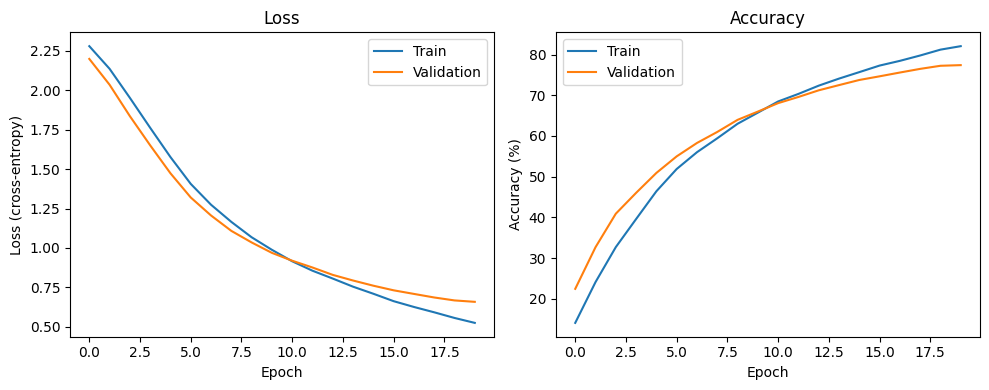

In [16]:
fig, axes = plot_learning_curves(history)
plt.show()

## 3. Evaluate model on test set

### 3.1. Calculate test accuracy

In [17]:
test_accuracy, predictions, true_labels = evaluate_model(model, test_loader)

### 3.2. Per-class accuracy

In [18]:
# Calculate per-class accuracy
class_correct = {name: 0 for name in class_names}
class_total = {name: 0 for name in class_names}

for pred, true in zip(predictions, true_labels):

    class_name = class_names[true]
    class_total[class_name] += 1

    if pred == true:
        class_correct[class_name] += 1

print('Per-class accuracy:')
print('-' * 30)

for name in class_names:
    acc = 100 * class_correct[name] / class_total[name]
    print(f'{name:12s}: {acc:.2f}%')

Per-class accuracy:
------------------------------
airplane    : 84.80%
automobile  : 86.30%
bird        : 72.10%
cat         : 57.60%
deer        : 79.70%
dog         : 70.80%
frog        : 81.40%
horse       : 83.00%
ship        : 83.30%
truck       : 81.00%


### 3.3. Confusion matrix

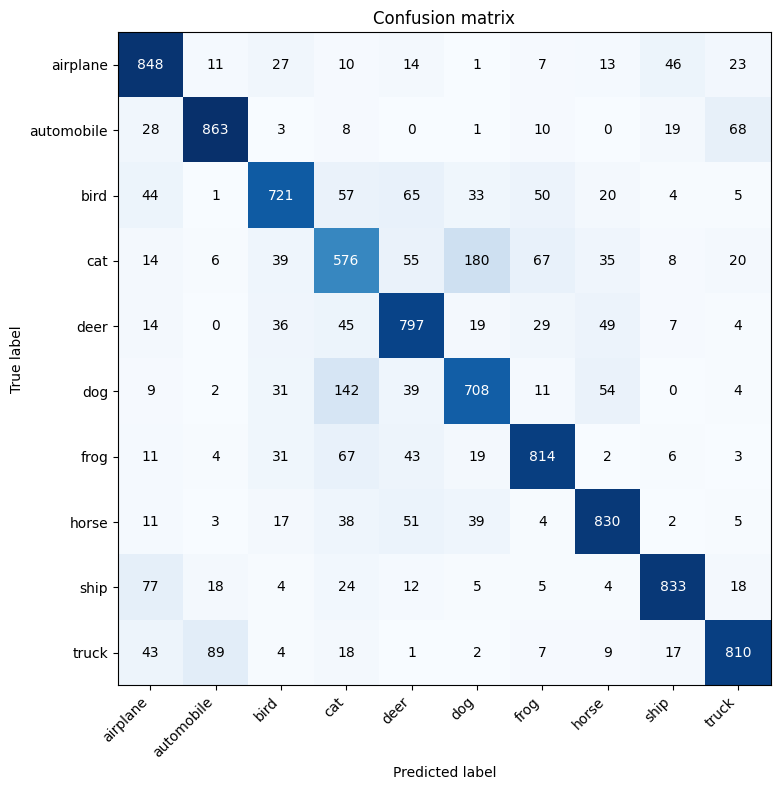

In [19]:
fig, ax = plot_confusion_matrix(true_labels, predictions, class_names)
plt.show()

### 3.4. Predicted class probability distributions

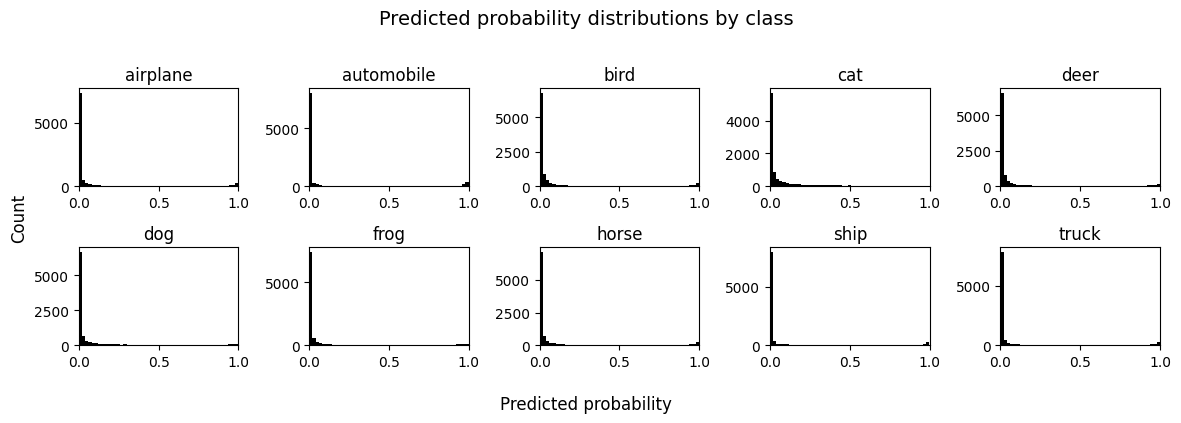

In [20]:
# Get predicted probabilities for all test samples
model.eval()
all_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

# Plot probability distributions
fig, axes = plot_class_probability_distributions(all_probs, class_names)
plt.show()

### 3.5. Evaluation curves

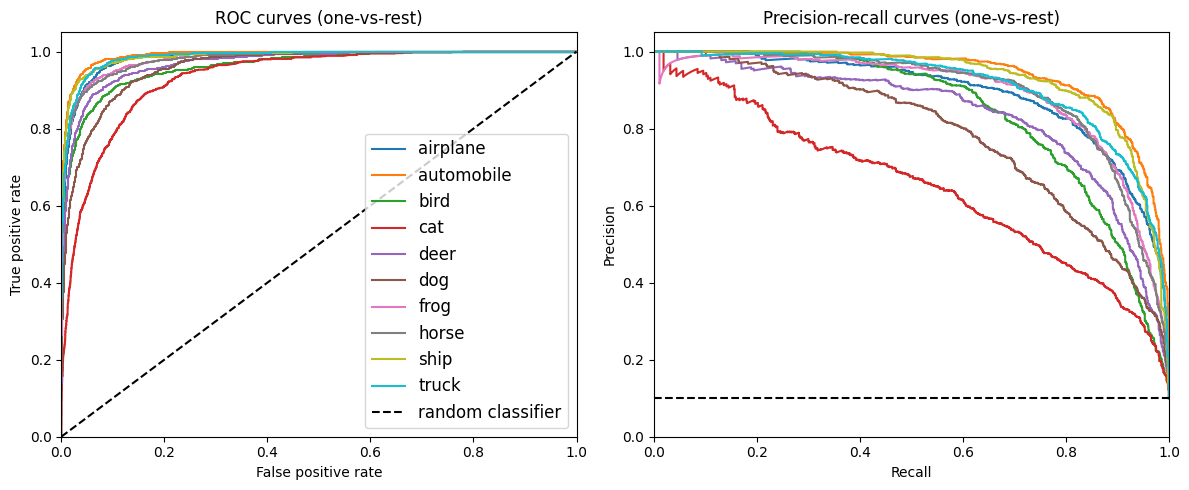

In [21]:
fig, (ax1, ax2) = plot_evaluation_curves(true_labels, all_probs, class_names)
plt.show()

## 4. Save model

In [22]:
# Save model state dict
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'test_accuracy': test_accuracy,
    'history': history
}, model_path)

print(f'Model saved to: {model_path}')
print(f'Test accuracy: {test_accuracy:.2f}%')

Model saved to: ../models/pytorch/rgb_cnn.pth
Test accuracy: 78.00%


## 5. Save test results for comparison

In [23]:
# Count model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create results dictionary
results_dict = {
    'true_labels': true_labels,
    'predictions': predictions,
    'all_probs': all_probs,
    'test_accuracy': test_accuracy,
    'total_params': total_params,
    'trainable_params': trainable_params
}

# Save results
with open(results_path, 'wb') as f:
    pickle.dump(results_dict, f)

print(f'Test results saved to: {results_path}')

print(f'  - Test accuracy: {test_accuracy:.2f}%')
print(f'  - Trainable parameters: {trainable_params:,}')
print(f'  - Total parameters: {total_params:,}')

Test results saved to: ../data/pytorch/performance_results/rgb_cnn_results.pkl
  - Test accuracy: 78.00%
  - Trainable parameters: 4,351,754
  - Total parameters: 23,520,906
